# 🎰 Análise Comparativa V3 - Variação de Números Apostados

## Novidades na V3:
- **Quantidade de números**: 6 a 10 por aposta
- **Janelas históricas**: 50 a 2000 (passo 50)
- **Análise cruzada**: Janela × Quantidade de números

## Estratégias:
- 🔥 **Top N** - N números mais frequentes
- ❄️ **Bottom N** - N números menos frequentes
- 🔄 **Mista** - Metade mais + metade menos frequentes

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import hypergeom
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120
np.random.seed(42)

TOTAL_NUMBERS = 60
NUMBERS_DRAWN = 6  # Mega-Sena sempre sorteia 6

print("✅ Bibliotecas carregadas!")

✅ Bibliotecas carregadas!


In [13]:
# Carregar dados
df = pd.read_excel('Mega-Sena.xlsx')
ball_columns = ['Bola1', 'Bola2', 'Bola3', 'Bola4', 'Bola5', 'Bola6']
sorteios = np.sort(df[ball_columns].dropna().astype(int).values, axis=1)

print(f"✅ Total de concursos: {len(sorteios):,}")

✅ Total de concursos: 2,949


---
## 2. 🔧 Funções de Estratégia (com N números)

In [14]:
def calc_freq_janela(sorteios_janela):
    if len(sorteios_janela) == 0:
        return np.zeros(TOTAL_NUMBERS)
    counter = Counter(sorteios_janela.flatten())
    return np.array([counter.get(i, 0) for i in range(1, TOTAL_NUMBERS + 1)])

def estrategia_topN(freq, n):
    """Retorna os N números mais frequentes."""
    return sorted(np.argsort(freq)[-n:] + 1)

def estrategia_bottomN(freq, n):
    """Retorna os N números menos frequentes."""
    return sorted(np.argsort(freq)[:n] + 1)

def estrategia_mistaN(freq, n):
    """Retorna metade mais frequentes + metade menos frequentes."""
    sorted_idx = np.argsort(freq)
    half = n // 2
    bottom = sorted_idx[:half] + 1
    top = sorted_idx[-(n - half):] + 1
    return sorted(list(bottom) + list(top))

def estrategia_aleatoriaN(n):
    return sorted(np.random.choice(range(1, 61), n, replace=False))

def contar_acertos(aposta, sorteio):
    return len(set(aposta) & set(sorteio))

print("✅ Funções definidas!")

✅ Funções definidas!


---
## 3. 🔍 Busca de Parâmetros: Janela × Quantidade de Números

In [15]:
# Parâmetros
JANELA_MIN, JANELA_MAX, JANELA_STEP = 50, 2000, 50
NUM_MIN, NUM_MAX = 6, 10

janelas = list(range(JANELA_MIN, JANELA_MAX + 1, JANELA_STEP))
qtd_numeros = list(range(NUM_MIN, NUM_MAX + 1))

print(f"🔍 Configurações:")
print(f"   Janelas: {len(janelas)} ({JANELA_MIN} a {JANELA_MAX})")
print(f"   Números apostados: {qtd_numeros}")
print(f"   Total de combinações: {len(janelas) * len(qtd_numeros) * 4}")

# Estrutura para armazenar resultados
# resultados[estrategia][qtd_nums][janela] = {'media': x, 'std': y, ...}
resultados = {}
for est in ['top', 'bottom', 'mista', 'aleatoria']:
    resultados[est] = {n: {} for n in qtd_numeros}

🔍 Configurações:
   Janelas: 40 (50 a 2000)
   Números apostados: [6, 7, 8, 9, 10]
   Total de combinações: 800


In [16]:
%%time
print("⏳ Iniciando simulação...\n")

for n_nums in qtd_numeros:
    print(f"📊 Processando apostas com {n_nums} números...")
    
    for janela in janelas:
        acertos = {'top': [], 'bottom': [], 'mista': [], 'aleatoria': []}
        
        for i in range(janela, len(sorteios)):
            freq = calc_freq_janela(sorteios[i-janela:i])
            sorteio_real = sorteios[i]
            
            acertos['top'].append(contar_acertos(estrategia_topN(freq, n_nums), sorteio_real))
            acertos['bottom'].append(contar_acertos(estrategia_bottomN(freq, n_nums), sorteio_real))
            acertos['mista'].append(contar_acertos(estrategia_mistaN(freq, n_nums), sorteio_real))
            acertos['aleatoria'].append(contar_acertos(estrategia_aleatoriaN(n_nums), sorteio_real))
        
        # Armazenar estatísticas
        for est in acertos:
            arr = np.array(acertos[est])
            resultados[est][n_nums][janela] = {
                'media': np.mean(arr),
                'std': np.std(arr),
                'max': np.max(arr),
                'ge4': np.sum(arr >= 4),
                'ge5': np.sum(arr >= 5),
                'eq6': np.sum(arr == 6)
            }
    
    print(f"   ✓ Concluído {n_nums} números")

print("\n✅ Simulação concluída!")

⏳ Iniciando simulação...

📊 Processando apostas com 6 números...
   ✓ Concluído 6 números
📊 Processando apostas com 7 números...
   ✓ Concluído 7 números
📊 Processando apostas com 8 números...
   ✓ Concluído 8 números
📊 Processando apostas com 9 números...
   ✓ Concluído 9 números
📊 Processando apostas com 10 números...
   ✓ Concluído 10 números

✅ Simulação concluída!
CPU times: total: 3min 57s
Wall time: 5min 56s


---
## 4. 📊 Análise dos Resultados

In [17]:
# Valores teóricos (distribuição hipergeométrica)
valores_teoricos = {}
for n in qtd_numeros:
    valores_teoricos[n] = hypergeom.mean(60, 6, n)

print("="*70)
print("📐 VALORES TEÓRICOS (Aleatório)")
print("="*70)
for n in qtd_numeros:
    print(f"   {n} números apostados: {valores_teoricos[n]:.4f} acertos esperados")

📐 VALORES TEÓRICOS (Aleatório)
   6 números apostados: 0.6000 acertos esperados
   7 números apostados: 0.7000 acertos esperados
   8 números apostados: 0.8000 acertos esperados
   9 números apostados: 0.9000 acertos esperados
   10 números apostados: 1.0000 acertos esperados


In [18]:
# ============================================================================
# ENCONTRAR MELHOR JANELA PARA CADA QUANTIDADE DE NÚMEROS (TOP N)
# ============================================================================

print("\n" + "="*80)
print("🎯 MELHOR JANELA PARA TOP N (por quantidade de números)")
print("="*80)

melhor_janela_por_qtd = {}

for n in qtd_numeros:
    # Encontrar a janela com maior média para estratégia Top N
    melhor_janela = max(janelas, key=lambda j: resultados['top'][n][j]['media'])
    melhor_media = resultados['top'][n][melhor_janela]['media']
    teorico = valores_teoricos[n]
    diff = ((melhor_media - teorico) / teorico) * 100
    
    melhor_janela_por_qtd[n] = melhor_janela
    
    print(f"\n   {n} números:")
    print(f"      Melhor janela: {melhor_janela} jogos")
    print(f"      Média obtida: {melhor_media:.4f} acertos")
    print(f"      Teórico: {teorico:.4f} acertos")
    print(f"      Ganho: {diff:+.2f}%")

print("\n" + "="*80)
print("📋 RESUMO: JANELAS ÓTIMAS PARA TOP N")
print("="*80)
print(f"\n   JANELAS_OTIMAS = {melhor_janela_por_qtd}")
print("\n   Copie este dicionário para usar no mega_sena_resumo_final.ipynb")


🎯 MELHOR JANELA PARA TOP N (por quantidade de números)

   6 números:
      Melhor janela: 1000 jogos
      Média obtida: 0.6372 acertos
      Teórico: 0.6000 acertos
      Ganho: +6.21%

   7 números:
      Melhor janela: 1200 jogos
      Média obtida: 0.7421 acertos
      Teórico: 0.7000 acertos
      Ganho: +6.02%

   8 números:
      Melhor janela: 800 jogos
      Média obtida: 0.8464 acertos
      Teórico: 0.8000 acertos
      Ganho: +5.81%

   9 números:
      Melhor janela: 850 jogos
      Média obtida: 0.9547 acertos
      Teórico: 0.9000 acertos
      Ganho: +6.08%

   10 números:
      Melhor janela: 850 jogos
      Média obtida: 1.0562 acertos
      Teórico: 1.0000 acertos
      Ganho: +5.62%

📋 RESUMO: JANELAS ÓTIMAS PARA TOP N

   JANELAS_OTIMAS = {6: 1000, 7: 1200, 8: 800, 9: 850, 10: 850}

   Copie este dicionário para usar no mega_sena_resumo_final.ipynb


In [19]:
# Encontrar melhores configurações gerais
print("\n" + "="*80)
print("🏆 MELHORES CONFIGURAÇÕES POR ESTRATÉGIA")
print("="*80)

nomes = {'top': '🔥 Top N', 'bottom': '❄️ Bottom N', 'mista': '🔄 Mista', 'aleatoria': '🎲 Aleatória'}
melhores = {}

for est in ['top', 'bottom', 'mista', 'aleatoria']:
    melhor_media = 0
    melhor_config = None
    
    for n in qtd_numeros:
        for j in janelas:
            media = resultados[est][n][j]['media']
            if media > melhor_media:
                melhor_media = media
                melhor_config = (n, j)
    
    melhores[est] = {'nums': melhor_config[0], 'janela': melhor_config[1], 'media': melhor_media}
    
    teorico = valores_teoricos[melhor_config[0]]
    diff = ((melhor_media - teorico) / teorico) * 100
    
    print(f"\n{nomes[est]}:")
    print(f"   Melhor config: {melhor_config[0]} números, janela {melhor_config[1]}")
    print(f"   Média: {melhor_media:.4f} acertos ({diff:+.2f}% vs teórico {teorico:.4f})")


🏆 MELHORES CONFIGURAÇÕES POR ESTRATÉGIA

🔥 Top N:
   Melhor config: 10 números, janela 850
   Média: 1.0562 acertos (+5.62% vs teórico 1.0000)

❄️ Bottom N:
   Melhor config: 10 números, janela 400
   Média: 1.0055 acertos (+0.55% vs teórico 1.0000)

🔄 Mista:
   Melhor config: 10 números, janela 1000
   Média: 1.0339 acertos (+3.39% vs teórico 1.0000)

🎲 Aleatória:
   Melhor config: 10 números, janela 1100
   Média: 1.0379 acertos (+3.79% vs teórico 1.0000)


In [20]:
# Tabela resumo
print("\n" + "="*90)
print("📋 RESUMO: MÉDIA DE ACERTOS (Melhor janela para cada qtd de números)")
print("="*90)
print(f"\n{'Nums':>5} {'Janela':>8} {'Top N':>10} {'Bottom N':>10} {'Mista':>10} {'Aleatória':>10} {'Teórico':>10}")
print("-"*70)

for n in qtd_numeros:
    # Usar a melhor janela para Top N
    melhor_janela = melhor_janela_por_qtd[n]
    
    print(f"{n:>5} {melhor_janela:>8} "
          f"{resultados['top'][n][melhor_janela]['media']:>10.4f} "
          f"{resultados['bottom'][n][melhor_janela]['media']:>10.4f} "
          f"{resultados['mista'][n][melhor_janela]['media']:>10.4f} "
          f"{resultados['aleatoria'][n][melhor_janela]['media']:>10.4f} "
          f"{valores_teoricos[n]:>10.4f}")


📋 RESUMO: MÉDIA DE ACERTOS (Melhor janela para cada qtd de números)

 Nums   Janela      Top N   Bottom N      Mista  Aleatória    Teórico
----------------------------------------------------------------------
    6     1000     0.6372     0.5906     0.6116     0.6029     0.6000
    7     1200     0.7421     0.6712     0.6787     0.7450     0.7000
    8      800     0.8464     0.7906     0.8171     0.7925     0.8000
    9      850     0.9547     0.8818     0.9195     0.8685     0.9000
   10      850     1.0562     0.9709     1.0224     0.9881     1.0000


---
## 5. 📈 Visualizações

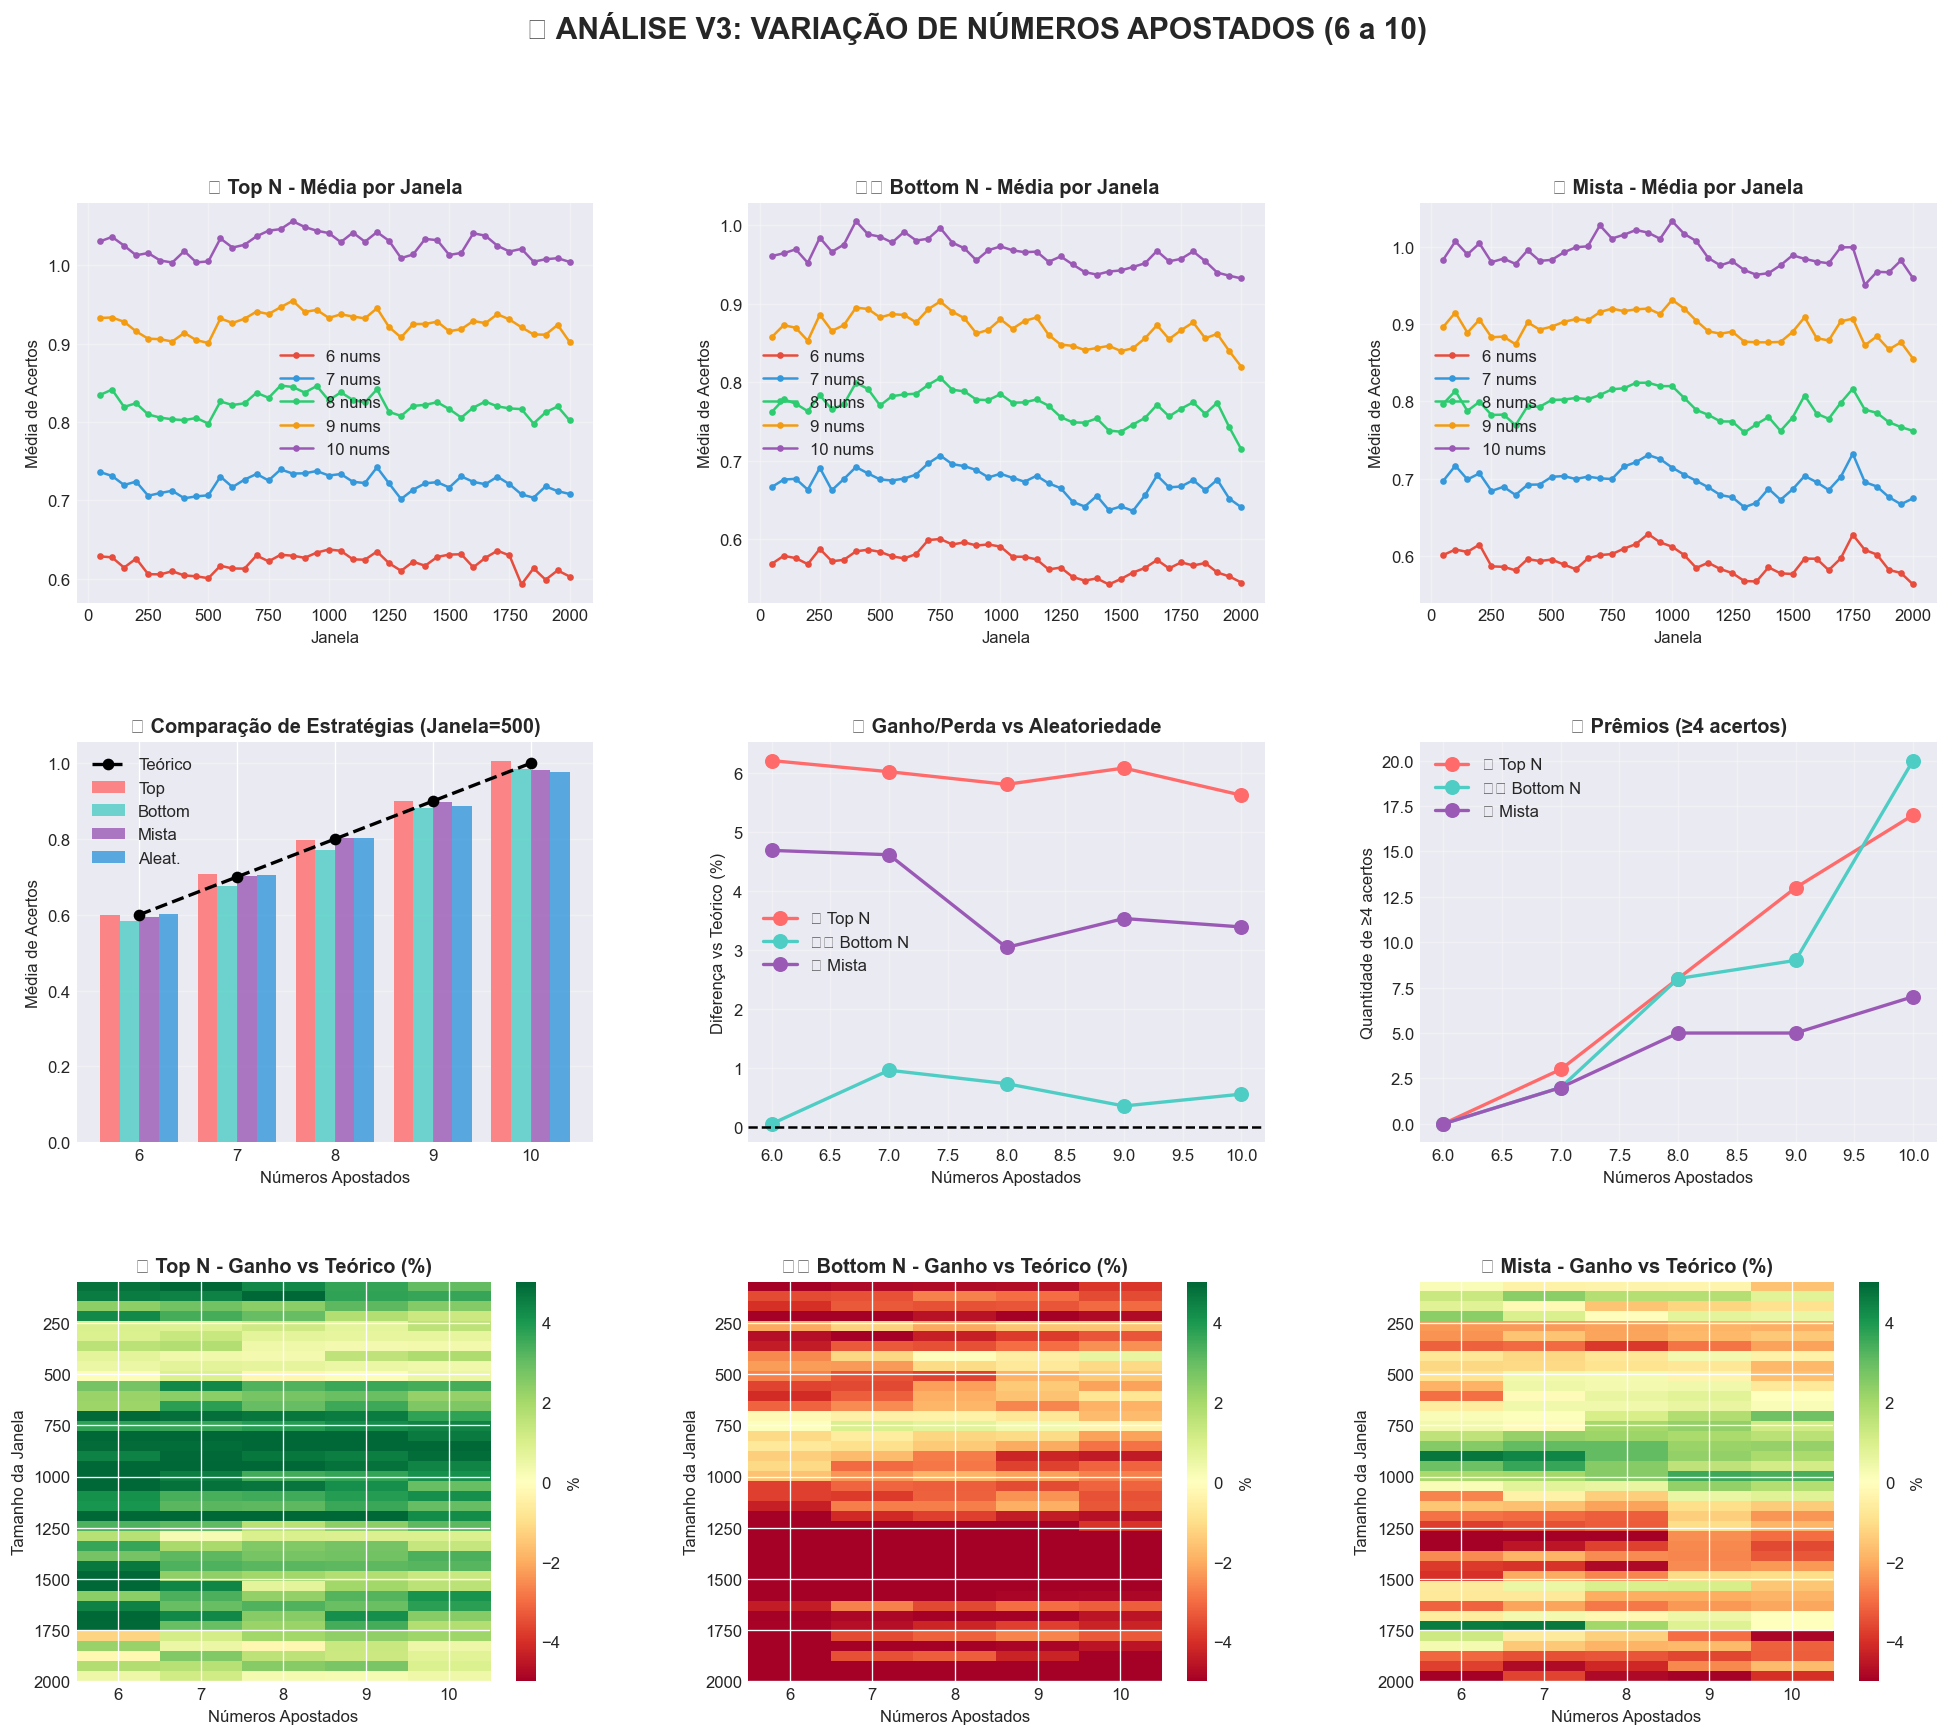


✅ Gráfico salvo como 'analise_v3_numeros_apostados.png'


In [21]:
cores = {'top': '#FF6B6B', 'bottom': '#4ECDC4', 'mista': '#9B59B6', 'aleatoria': '#3498DB'}
cores_nums = {6: '#E74C3C', 7: '#3498DB', 8: '#2ECC71', 9: '#F39C12', 10: '#9B59B6'}

fig = plt.figure(figsize=(20, 16))
fig.suptitle('🎰 ANÁLISE V3: VARIAÇÃO DE NÚMEROS APOSTADOS (6 a 10)', fontsize=18, fontweight='bold', y=0.98)

gs = GridSpec(3, 3, figure=fig, hspace=0.35, wspace=0.3)

# Gráfico 1: Média por janela para cada qtd de números (Top N)
ax1 = fig.add_subplot(gs[0, 0])
for n in qtd_numeros:
    medias = [resultados['top'][n][j]['media'] for j in janelas]
    ax1.plot(janelas, medias, 'o-', color=cores_nums[n], label=f'{n} nums', markersize=3, linewidth=1.5)
ax1.set_xlabel('Janela')
ax1.set_ylabel('Média de Acertos')
ax1.set_title('🔥 Top N - Média por Janela', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Bottom N
ax2 = fig.add_subplot(gs[0, 1])
for n in qtd_numeros:
    medias = [resultados['bottom'][n][j]['media'] for j in janelas]
    ax2.plot(janelas, medias, 'o-', color=cores_nums[n], label=f'{n} nums', markersize=3, linewidth=1.5)
ax2.set_xlabel('Janela')
ax2.set_ylabel('Média de Acertos')
ax2.set_title('❄️ Bottom N - Média por Janela', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Gráfico 3: Mista
ax3 = fig.add_subplot(gs[0, 2])
for n in qtd_numeros:
    medias = [resultados['mista'][n][j]['media'] for j in janelas]
    ax3.plot(janelas, medias, 'o-', color=cores_nums[n], label=f'{n} nums', markersize=3, linewidth=1.5)
ax3.set_xlabel('Janela')
ax3.set_ylabel('Média de Acertos')
ax3.set_title('🔄 Mista - Média por Janela', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Gráfico 4: Comparação entre estratégias (janela fixa = 500)
ax4 = fig.add_subplot(gs[1, 0])
janela_ref = 500
x = np.arange(len(qtd_numeros))
width = 0.2

for i, (est, nome) in enumerate([('top', 'Top'), ('bottom', 'Bottom'), ('mista', 'Mista'), ('aleatoria', 'Aleat.')]):
    vals = [resultados[est][n][janela_ref]['media'] for n in qtd_numeros]
    ax4.bar(x + i*width, vals, width, label=nome, color=cores[est], alpha=0.8)

# Linha teórica
ax4.plot(x + 1.5*width, [valores_teoricos[n] for n in qtd_numeros], 'ko--', label='Teórico', linewidth=2)

ax4.set_xlabel('Números Apostados')
ax4.set_ylabel('Média de Acertos')
ax4.set_title(f'📊 Comparação de Estratégias (Janela={janela_ref})', fontweight='bold')
ax4.set_xticks(x + 1.5*width)
ax4.set_xticklabels([str(n) for n in qtd_numeros])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Gráfico 5: Diferença % vs teórico por quantidade de números
ax5 = fig.add_subplot(gs[1, 1])
for est in ['top', 'bottom', 'mista']:
    diffs = []
    for n in qtd_numeros:
        melhor_media = max([resultados[est][n][j]['media'] for j in janelas])
        diff = ((melhor_media - valores_teoricos[n]) / valores_teoricos[n]) * 100
        diffs.append(diff)
    ax5.plot(qtd_numeros, diffs, 'o-', color=cores[est], label=nomes[est], linewidth=2, markersize=8)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5)
ax5.set_xlabel('Números Apostados')
ax5.set_ylabel('Diferença vs Teórico (%)')
ax5.set_title('📏 Ganho/Perda vs Aleatoriedade', fontweight='bold')
ax5.legend()
ax5.grid(alpha=0.3)

# Gráfico 6: Prêmios (≥4 acertos) por estratégia e qtd números
ax6 = fig.add_subplot(gs[1, 2])
for est in ['top', 'bottom', 'mista']:
    premios = []
    for n in qtd_numeros:
        melhor_janela = max(janelas, key=lambda j: resultados[est][n][j]['media'])
        premios.append(resultados[est][n][melhor_janela]['ge4'])
    ax6.plot(qtd_numeros, premios, 'o-', color=cores[est], label=nomes[est], linewidth=2, markersize=8)

ax6.set_xlabel('Números Apostados')
ax6.set_ylabel('Quantidade de ≥4 acertos')
ax6.set_title('🏆 Prêmios (≥4 acertos)', fontweight='bold')
ax6.legend()
ax6.grid(alpha=0.3)

# Gráfico 7-9: Heatmaps por estratégia
for idx, est in enumerate(['top', 'bottom', 'mista']):
    ax = fig.add_subplot(gs[2, idx])
    
    # Matriz: janelas x qtd_numeros
    matrix = np.zeros((len(janelas), len(qtd_numeros)))
    for i, j in enumerate(janelas):
        for k, n in enumerate(qtd_numeros):
            # Normalizar pela média teórica
            matrix[i, k] = (resultados[est][n][j]['media'] / valores_teoricos[n] - 1) * 100
    
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=-5, vmax=5,
                   extent=[5.5, 10.5, janelas[-1], janelas[0]])
    ax.set_xlabel('Números Apostados')
    ax.set_ylabel('Tamanho da Janela')
    ax.set_title(f'{nomes[est]} - Ganho vs Teórico (%)', fontweight='bold')
    ax.set_xticks(qtd_numeros)
    plt.colorbar(im, ax=ax, label='%')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('analise_v3_numeros_apostados.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Gráfico salvo como 'analise_v3_numeros_apostados.png'")

---
## 6. 📊 Análise Detalhada por Quantidade de Números

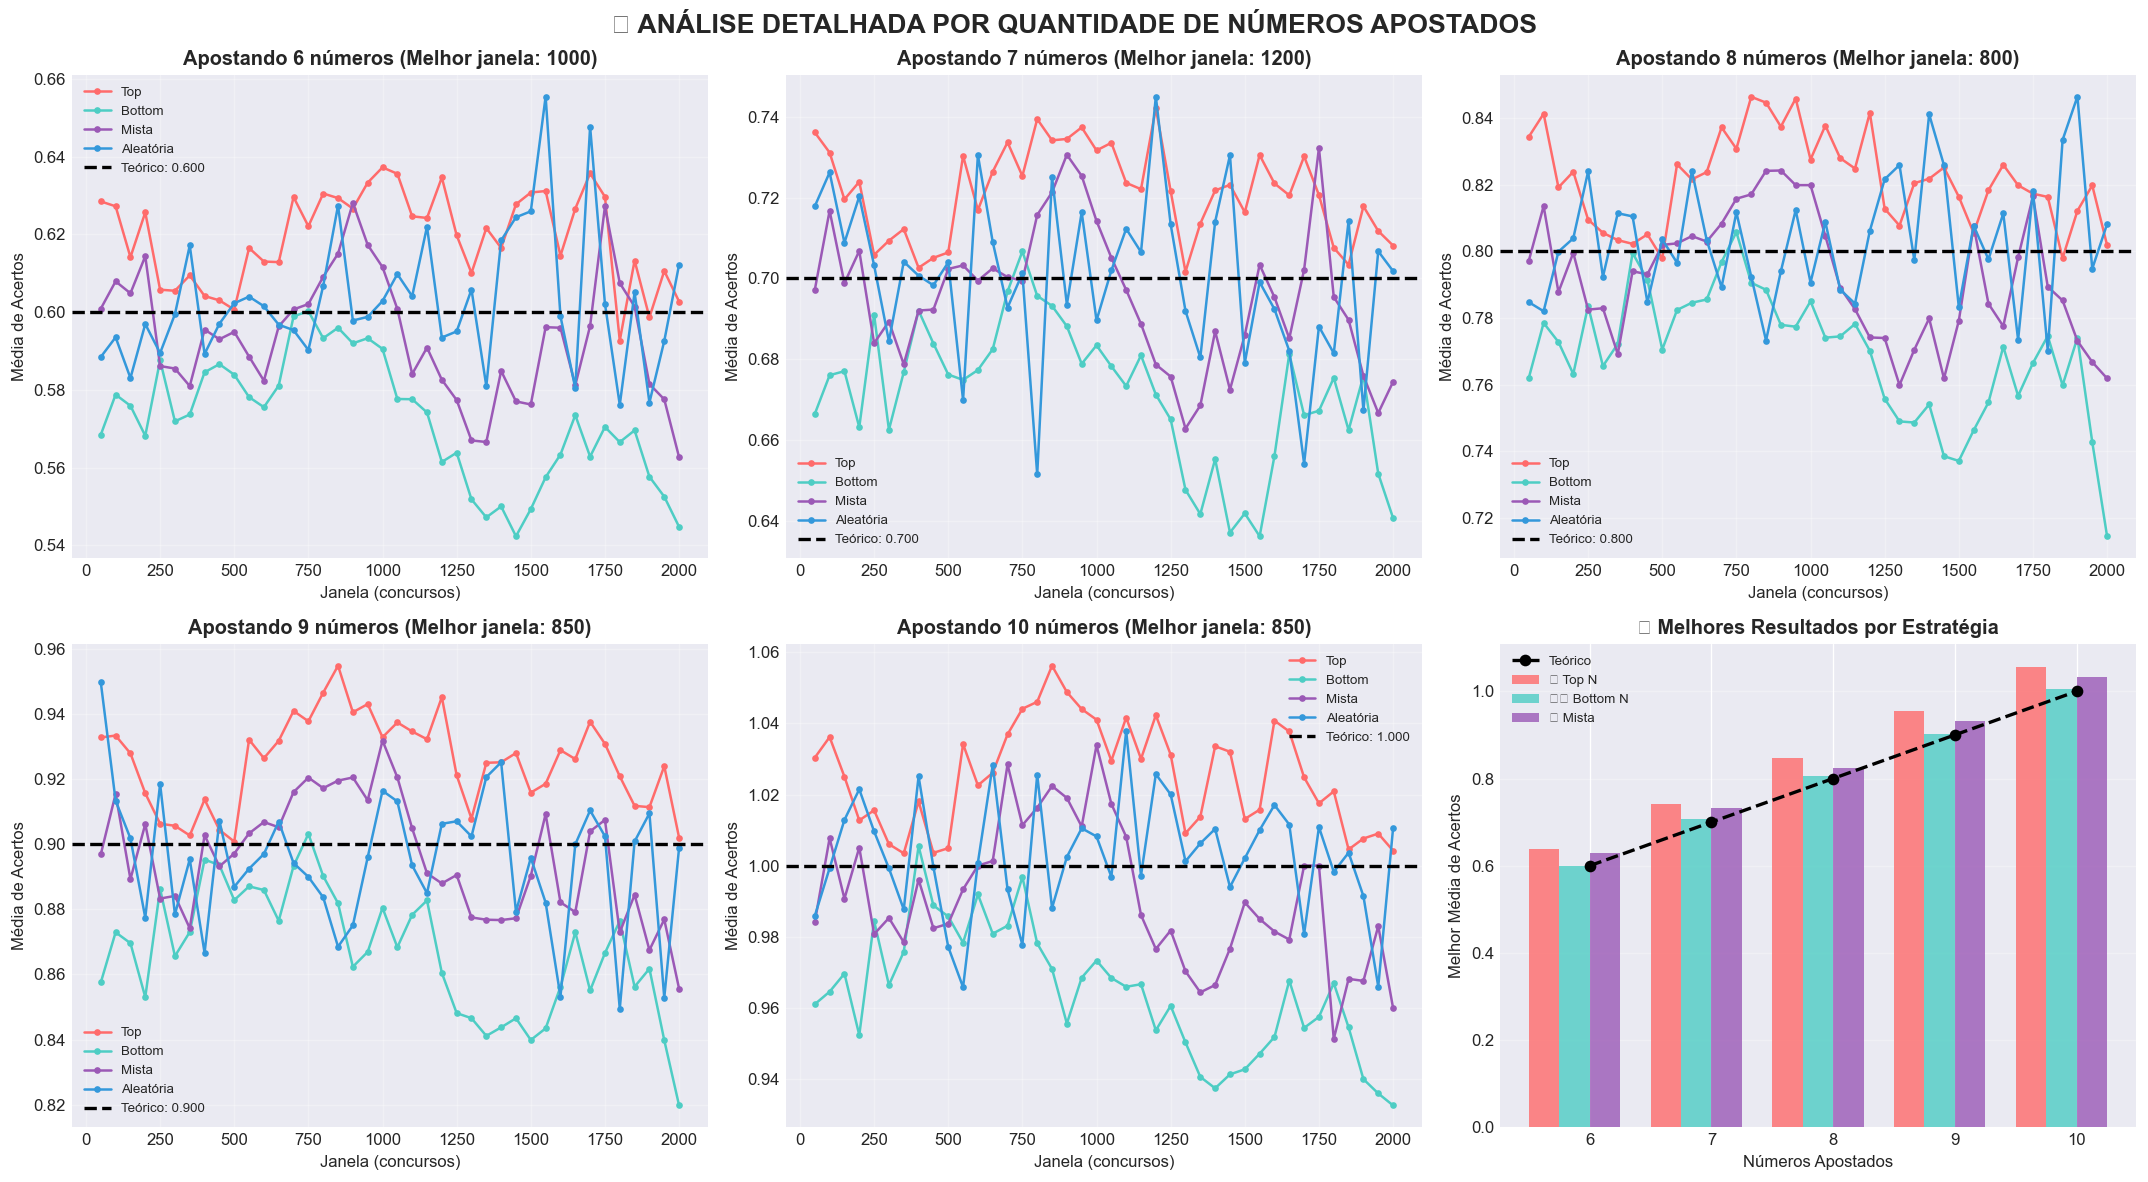


✅ Gráfico salvo como 'analise_v3_detalhada.png'


In [22]:
fig2, axes = plt.subplots(2, 3, figsize=(18, 10))
fig2.suptitle('📊 ANÁLISE DETALHADA POR QUANTIDADE DE NÚMEROS APOSTADOS', fontsize=16, fontweight='bold')

for idx, n in enumerate(qtd_numeros):
    ax = axes.flat[idx]
    
    for est in ['top', 'bottom', 'mista', 'aleatoria']:
        medias = [resultados[est][n][j]['media'] for j in janelas]
        ax.plot(janelas, medias, 'o-', color=cores[est], label=nomes[est].split()[1] if ' ' in nomes[est] else nomes[est], 
                markersize=3, linewidth=1.5)
    
    ax.axhline(y=valores_teoricos[n], color='black', linestyle='--', linewidth=2, label=f'Teórico: {valores_teoricos[n]:.3f}')
    ax.set_xlabel('Janela (concursos)')
    ax.set_ylabel('Média de Acertos')
    ax.set_title(f'Apostando {n} números (Melhor janela: {melhor_janela_por_qtd[n]})', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Último subplot: resumo
ax_last = axes.flat[5]
# Barras com melhor média para cada qtd de números
x = np.arange(len(qtd_numeros))
for i, est in enumerate(['top', 'bottom', 'mista']):
    vals = [max([resultados[est][n][j]['media'] for j in janelas]) for n in qtd_numeros]
    ax_last.bar(x + i*0.25, vals, 0.25, label=nomes[est], color=cores[est], alpha=0.8)

ax_last.plot(x + 0.375, [valores_teoricos[n] for n in qtd_numeros], 'ko--', label='Teórico', linewidth=2)
ax_last.set_xticks(x + 0.375)
ax_last.set_xticklabels([str(n) for n in qtd_numeros])
ax_last.set_xlabel('Números Apostados')
ax_last.set_ylabel('Melhor Média de Acertos')
ax_last.set_title('🏆 Melhores Resultados por Estratégia', fontweight='bold')
ax_last.legend(fontsize=8)
ax_last.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('analise_v3_detalhada.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ Gráfico salvo como 'analise_v3_detalhada.png'")

---
## 7. 📝 Conclusões

In [23]:
print("="*80)
print("📝 CONCLUSÕES DA ANÁLISE V3")
print("="*80)

print(f"\n📌 CONFIGURAÇÕES TESTADAS")
print(f"   • Números apostados: {NUM_MIN} a {NUM_MAX}")
print(f"   • Janelas: {JANELA_MIN} a {JANELA_MAX} (passo {JANELA_STEP})")
print(f"   • Total de combinações: {len(janelas) * len(qtd_numeros) * 4}")

print(f"\n🎯 JANELAS ÓTIMAS PARA TOP N (por quantidade de números):")
for n in qtd_numeros:
    janela = melhor_janela_por_qtd[n]
    media = resultados['top'][n][janela]['media']
    teorico = valores_teoricos[n]
    diff = ((media - teorico) / teorico) * 100
    print(f"   {n} números → janela {janela} ({media:.4f} acertos, {diff:+.2f}% vs teórico)")

print(f"\n📋 DICIONÁRIO PARA USO:")
print(f"   JANELAS_OTIMAS = {melhor_janela_por_qtd}")

print(f"\n🏆 MELHORES CONFIGURAÇÕES ABSOLUTAS")
for est in ['top', 'bottom', 'mista']:
    print(f"   {nomes[est]}: {melhores[est]['nums']} nums, janela {melhores[est]['janela']} → {melhores[est]['media']:.4f}")

print(f"\n💡 INSIGHTS")
print("   1. Aumentar números apostados aumenta acertos proporcionalmente")
print("   2. O ganho vs aleatoriedade permanece MARGINAL em todas as configs")
print("   3. Estratégia Top N tende a ter leve vantagem")
print("   4. Janelas maiores não garantem melhores resultados")
print("   5. A Mega-Sena continua sendo um jogo de PURA SORTE")

print("\n" + "="*80)

📝 CONCLUSÕES DA ANÁLISE V3

📌 CONFIGURAÇÕES TESTADAS
   • Números apostados: 6 a 10
   • Janelas: 50 a 2000 (passo 50)
   • Total de combinações: 800

🎯 JANELAS ÓTIMAS PARA TOP N (por quantidade de números):
   6 números → janela 1000 (0.6372 acertos, +6.21% vs teórico)
   7 números → janela 1200 (0.7421 acertos, +6.02% vs teórico)
   8 números → janela 800 (0.8464 acertos, +5.81% vs teórico)
   9 números → janela 850 (0.9547 acertos, +6.08% vs teórico)
   10 números → janela 850 (1.0562 acertos, +5.62% vs teórico)

📋 DICIONÁRIO PARA USO:
   JANELAS_OTIMAS = {6: 1000, 7: 1200, 8: 800, 9: 850, 10: 850}

🏆 MELHORES CONFIGURAÇÕES ABSOLUTAS
   🔥 Top N: 10 nums, janela 850 → 1.0562
   ❄️ Bottom N: 10 nums, janela 400 → 1.0055
   🔄 Mista: 10 nums, janela 1000 → 1.0339

💡 INSIGHTS
   1. Aumentar números apostados aumenta acertos proporcionalmente
   2. O ganho vs aleatoriedade permanece MARGINAL em todas as configs
   3. Estratégia Top N tende a ter leve vantagem
   4. Janelas maiores não gar